In [1]:
import warnings
warnings.filterwarnings("ignore")

### Cell 1: Text Cleaning & Dataset Preparation

In [2]:
import pandas as pd
import re
import string

# ------------------------------
# Text cleaning functions
# ------------------------------

def remove_punctuation(text):
    if pd.isna(text):
        return text
    return text.translate(str.maketrans('', '', string.punctuation))

def remove_whitespace(text):
    if pd.isna(text):
        return text
    return " ".join(text.split())

def remove_emojis(text):
    if pd.isna(text):
        return text
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def remove_urls(text):
    if pd.isna(text):
        return text
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_html(text):
    if pd.isna(text):
        return text
    html_pattern = re.compile(r'<.*?>')
    return html_pattern.sub(r'', text)

def remove_special_characters(text):
    if pd.isna(text):
        return text
    return re.sub(r'[^A-Za-z0-9\s\u0980-\u09FF]', '', text)

def clean_text(text):
    text = remove_urls(text)
    text = remove_html(text)
    text = remove_emojis(text)
    text = remove_punctuation(text)
    text = remove_special_characters(text)
    text = remove_whitespace(text)
    return text

# ================================
# Dataset Paths
# ================================
IMAGE_FOLDER = "/kaggle/input/datasets/ariful234/clickbait/Clickbait/Thumbnails"
TRAIN_CSV    = "/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/train.csv"
VAL_CSV      = "/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/val.csv"
TEST_CSV     = "/kaggle/input/datasets/ariful234/banclickthumb-bangla-clickbait-dataset/BanClickThumb-Bangla Clickbait Dataset/test.csv"

# ================================
# Load, clean & save each split
# ================================
splits = {
    'train': (TRAIN_CSV, '/kaggle/working/train_cleaned.csv'),
    'val':   (VAL_CSV,   '/kaggle/working/validation_cleaned.csv'),
    'test':  (TEST_CSV,  '/kaggle/working/test_cleaned.csv'),
}

for split_name, (input_path, output_path) in splits.items():
    df = pd.read_csv(input_path)
    df = df[['Image Path', 'Title', 'label']]
    df = df.dropna(subset=['label']).reset_index(drop=True)
    df['label'] = df['label'].astype(int)
    df['Title'] = df['Title'].astype(str).apply(clean_text)
    df.to_csv(output_path, index=False)
    print(f"[{split_name}] shape: {df.shape}, saved to {output_path}")
    print(df['label'].value_counts(), "\n")

[train] shape: (5002, 3), saved to /kaggle/working/train_cleaned.csv
label
0    2886
1    2116
Name: count, dtype: int64 

[val] shape: (715, 3), saved to /kaggle/working/validation_cleaned.csv
label
0    412
1    303
Name: count, dtype: int64 

[test] shape: (1430, 3), saved to /kaggle/working/test_cleaned.csv
label
0    825
1    605
Name: count, dtype: int64 



### Cell 2: Preview Cleaned Data

In [3]:
train_df = pd.read_csv('/kaggle/working/train_cleaned.csv')
print("Train:"); train_df.head()

Train:


,Image Path,Title,label
0,Thumbnails/thumbnail_9062.jpg,ব্রেন স্ট্রোকের লক্ষণ গুলি কি Brain Stroke Sym...,1
1,Thumbnails/thumbnail_8722.jpg,২য় শ্রেণি গণিত নমুনা প্রশ্ন ও উত্তর ২০২৫ ১ম স...,0
2,Thumbnails/thumbnail_13793.jpg,চ্যালেঞ্জ সামলাতে পারবে যুক্তরাষ্ট্রের সাথে সম...,1
3,Thumbnails/thumbnail_15025.jpg,কুমির চাষে আয় ১৫ কোটি টাকা না দেখলে বিশ্বাস ক...,1
4,Thumbnails/thumbnail_13884.jpg,আ লীগ নির্বাচনে থাকবে কিনা সিদ্ধান্ত কার ওপর ছ...,0


In [4]:
val_df = pd.read_csv('/kaggle/working/validation_cleaned.csv')
print("Val:"); val_df.head()

Val:


,Image Path,Title,label
0,Thumbnails/thumbnail_6549.jpg,হাসিনার প্লট জালিয়াতি ফাঁসছেন ২০ কর্মকর্তা DU...,0
1,Thumbnails/thumbnail_14236.jpg,কক্সবাজারে এনসিপি নেতাদের গাড়িবহরে হামলা Coxs...,0
2,Thumbnails/thumbnail_13301.jpg,WBCHSE 2025 Results LIVE উচ্চমাধ্যমিকের ফলাফল ...,0
3,Thumbnails/thumbnail_6204.jpg,কাল থেকে পুরোদমে শুরু হচ্ছে দেশের শিক্ষা কার্য...,1
4,Thumbnails/thumbnail_5862.jpg,নবম শ্রেণীর পাঠ্যবই নিয়ে যে তথ্য দিলেন আসিফ ম...,0


In [5]:
test_df = pd.read_csv('/kaggle/working/test_cleaned.csv')
print("Test:"); test_df.head()

Test:


,Image Path,Title,label
0,Thumbnails/thumbnail_2775.jpg,অহংকারের পরিণতি কি মুফতি সাইফুল্লাহ মাহমুদআল্ল...,0
1,Thumbnails/thumbnail_12266.jpg,ইলেকট্রিক কেটলিতে পানি গরম করলে কত টাকা বিদ্যু...,1
2,Thumbnails/thumbnail_11645.jpg,বনসংরক্ষণ প্রবন্ধ রচনা মাধ্যমিক ও উচ্চমাধ্যমিক...,0
3,Thumbnails/thumbnail_8109.jpg,টপ ৫ ইতিহাসের সবচেয়ে ভয়াবহ প্রাকৃতিক দুর্যোগ...,1
4,Thumbnails/thumbnail_3045.jpg,পাকিস্তানিরা কেন শেখ মুজিবের চেয়ে তাজউদ্দীনকে...,1


### Cell 3: Libraries Install & Imports

In [6]:
!pip install -q timm transformers

In [7]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel   # mBERT
import timm
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import pandas as pd
import torchvision.transforms as transforms

# ================================
# Configuration (Global Settings)
# ================================
Config = {
    'MAX_LEN': 64,
    'BATCH_SIZE': 32,
    'EPOCHS': 15,
    'LEARNING_RATE': 2e-5,
    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu',
    'IMG_SIZE': 224,
    'TEXT_MODEL': 'bert-base-multilingual-cased',   # mBERT
    'IMAGE_MODEL': 'vit_base_patch16_224',           # ViT-Base
    'NUM_CLASSES': 2,
    'IMAGE_ROOT': "/kaggle/input/datasets/ariful234/clickbait/Clickbait/Thumbnails"
}

print(f"Configuration set. Device: {Config['DEVICE']}")

Configuration set. Device: cuda


### Cell 4: Custom Dataset Class

In [8]:
class ClickbaitDataset(Dataset):
    def __init__(self, csv_path, tokenizer, transform=None, root_dir=''):
        self.df = pd.read_csv(csv_path)
        self.tokenizer = tokenizer
        self.transform = transform
        self.root_dir = root_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # --- 1. Text Processing (mBERT tokenizer) ---
        text = str(row['Title'])

        inputs = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=Config['MAX_LEN'],
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=True,   # mBERT uses token_type_ids
            return_tensors='pt'
        )

        # --- 2. Image Processing ---
        img_path = row['Image Path']
        if self.root_dir:
            full_img_path = os.path.join(self.root_dir, img_path)
        else:
            full_img_path = img_path

        try:
            image = Image.open(full_img_path).convert("RGB")
        except Exception:
            image = Image.new('RGB', (Config['IMG_SIZE'], Config['IMG_SIZE']))

        if self.transform:
            image = self.transform(image)

        return {
            'input_ids':      inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'token_type_ids': inputs['token_type_ids'].flatten(),  # mBERT specific
            'image':          image,
            'label':          torch.tensor(row['label'], dtype=torch.long)
        }

print("Dataset class defined.")

Dataset class defined.


### Cell 5: Model Architecture (Early Fusion — ViT + mBERT)

In [9]:
class ViTMBertFusion(nn.Module):
    def __init__(self):
        super(ViTMBertFusion, self).__init__()

        # --- Text Encoder (mBERT) ---
        self.text_encoder = BertModel.from_pretrained(Config['TEXT_MODEL'])
        text_hidden_size = self.text_encoder.config.hidden_size  # 768

        # --- Image Encoder (ViT) ---
        # num_classes=0 removes the classification head; returns raw patch embeddings
        self.img_encoder = timm.create_model(Config['IMAGE_MODEL'], pretrained=True, num_classes=0)
        img_hidden_size = self.img_encoder.num_features  # 768 for ViT-Base

        # --- Early Fusion Layer ---
        fusion_input_dim = text_hidden_size + img_hidden_size

        self.classifier = nn.Sequential(
            nn.Linear(fusion_input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, Config['NUM_CLASSES'])
        )

    def forward(self, input_ids, attention_mask, token_type_ids, images):
        # 1. Text Features — [CLS] token from mBERT
        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        text_features = text_outputs.last_hidden_state[:, 0, :]  # [CLS] token

        # 2. Image Features — [CLS] token from ViT
        img_features = self.img_encoder(images)  # shape: (batch, 768)

        # 3. Early Fusion — Concatenate text + image features
        combined_features = torch.cat((text_features, img_features), dim=1)

        # 4. Classification
        logits = self.classifier(combined_features)
        return logits

print("Model architecture defined.")

Model architecture defined.


### Cell 6: Data Loaders & Initialization

In [10]:
# 1. Define Transforms
# ViT requires exactly 224x224 with ImageNet normalization
train_transform = transforms.Compose([
    transforms.Resize((Config['IMG_SIZE'], Config['IMG_SIZE'])),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((Config['IMG_SIZE'], Config['IMG_SIZE'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load mBERT Tokenizer
tokenizer = BertTokenizer.from_pretrained(Config['TEXT_MODEL'])

# 3. Create Datasets & Loaders
train_dataset = ClickbaitDataset('/kaggle/working/train_cleaned.csv',      tokenizer, train_transform, root_dir=Config['IMAGE_ROOT'])
val_dataset   = ClickbaitDataset('/kaggle/working/validation_cleaned.csv', tokenizer, val_transform,   root_dir=Config['IMAGE_ROOT'])

train_loader = DataLoader(train_dataset, batch_size=Config['BATCH_SIZE'], shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=Config['BATCH_SIZE'], shuffle=False, num_workers=2)

# 4. Initialize Model, Loss, Optimizer
model     = ViTMBertFusion().to(Config['DEVICE'])
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=Config['LEARNING_RATE'])

print("Data loaded and Model initialized successfully.")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Data loaded and Model initialized successfully.


### Cell 7: Training Loop

In [11]:
print(f"Starting training on {Config['DEVICE']} for {Config['EPOCHS']} epochs...")

for epoch in range(Config['EPOCHS']):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config['EPOCHS']}")

    for batch in loop:
        input_ids      = batch['input_ids'].to(Config['DEVICE'])
        attention_mask = batch['attention_mask'].to(Config['DEVICE'])
        token_type_ids = batch['token_type_ids'].to(Config['DEVICE'])  # mBERT specific
        images         = batch['image'].to(Config['DEVICE'])
        labels         = batch['label'].to(Config['DEVICE'])

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, token_type_ids, images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Train Accuracy: {100 * correct / total:.2f}%")

    # --- Validation Loop ---
    model.eval()
    val_preds  = []
    val_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(Config['DEVICE'])
            attention_mask = batch['attention_mask'].to(Config['DEVICE'])
            token_type_ids = batch['token_type_ids'].to(Config['DEVICE'])
            images         = batch['image'].to(Config['DEVICE'])
            labels         = batch['label'].to(Config['DEVICE'])

            outputs = model(input_ids, attention_mask, token_type_ids, images)
            _, predicted = torch.max(outputs, 1)

            val_preds.extend(predicted.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    print(f"Epoch {epoch+1} Validation Accuracy: {val_acc*100:.2f}%")
    print("-" * 30)

torch.save(model.state_dict(), '/kaggle/working/vit_mbert_fusion.pth')
print("Training Complete & Model Saved!")

Starting training on cuda for 15 epochs...


Epoch 1/15: 100%|██████████| 157/157 [04:06<00:00,  1.57s/it, loss=0.438]

Epoch 1 Train Accuracy: 66.01%


Epoch 1 Validation Accuracy: 74.13%
------------------------------


Epoch 2/15: 100%|██████████| 157/157 [04:10<00:00,  1.60s/it, loss=0.47] 

...

Epoch 14 Train Accuracy: 98.64%


Epoch 14 Validation Accuracy: 78.46%
------------------------------


Epoch 15/15: 100%|██████████| 157/157 [04:10<00:00,  1.60s/it, loss=0.161]  

Epoch 15 Train Accuracy: 98.64%


Epoch 15 Validation Accuracy: 78.32%
------------------------------
Training Complete & Model Saved!


### Cell 8: Performance Evaluation (Confusion Matrix & Metrics)

Loading Test Data...
Generating predictions on Test Set...


Testing: 100%|██████████| 45/45 [00:24<00:00,  1.84it/s]



✅ Test Accuracy: 80.00%

📊 Classification Report:
                   precision    recall  f1-score   support

Non-Clickbait (0)       0.84      0.80      0.82       825
    Clickbait (1)       0.75      0.80      0.77       605

         accuracy                           0.80      1430
        macro avg       0.80      0.80      0.80      1430
     weighted avg       0.80      0.80      0.80      1430



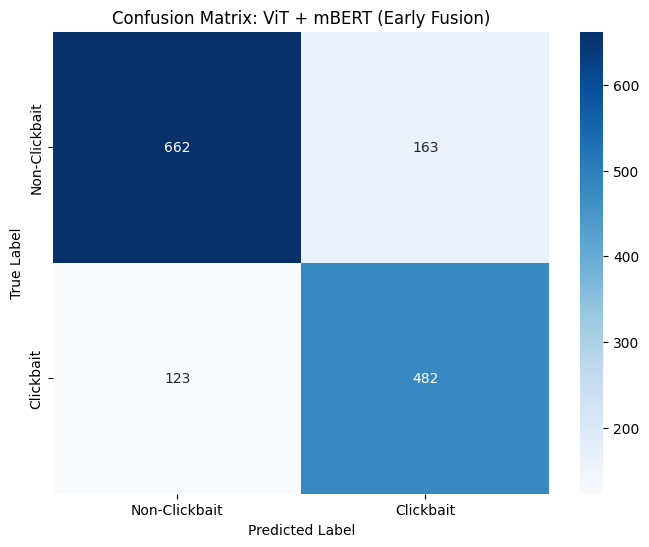

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

# ==========================================
# 1. Load Test Data
# ==========================================
print("Loading Test Data...")
test_dataset = ClickbaitDataset(
    csv_path='/kaggle/working/test_cleaned.csv',
    tokenizer=tokenizer,
    transform=val_transform,
    root_dir=Config['IMAGE_ROOT']
)

test_loader = DataLoader(test_dataset, batch_size=Config['BATCH_SIZE'], shuffle=False, num_workers=2)

# ==========================================
# 2. Get Predictions
# ==========================================
model.eval()
y_true = []
y_pred = []

print("Generating predictions on Test Set...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids      = batch['input_ids'].to(Config['DEVICE'])
        attention_mask = batch['attention_mask'].to(Config['DEVICE'])
        token_type_ids = batch['token_type_ids'].to(Config['DEVICE'])
        images         = batch['image'].to(Config['DEVICE'])
        labels         = batch['label'].to(Config['DEVICE'])

        outputs = model(input_ids, attention_mask, token_type_ids, images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# ==========================================
# 3. Calculate Metrics
# ==========================================
accuracy = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {accuracy*100:.2f}%")

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Non-Clickbait (0)', 'Clickbait (1)']))

# ==========================================
# 4. Plot Confusion Matrix
# ==========================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Clickbait', 'Clickbait'],
            yticklabels=['Non-Clickbait', 'Clickbait'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: ViT + mBERT (Early Fusion)')
plt.show()

### Cell 9: ROC Curve & AUC

Gathering probabilities for ROC curve...


ROC Inference: 100%|██████████| 45/45 [00:24<00:00,  1.83it/s]


✅ ROC AUC Score: 0.8451


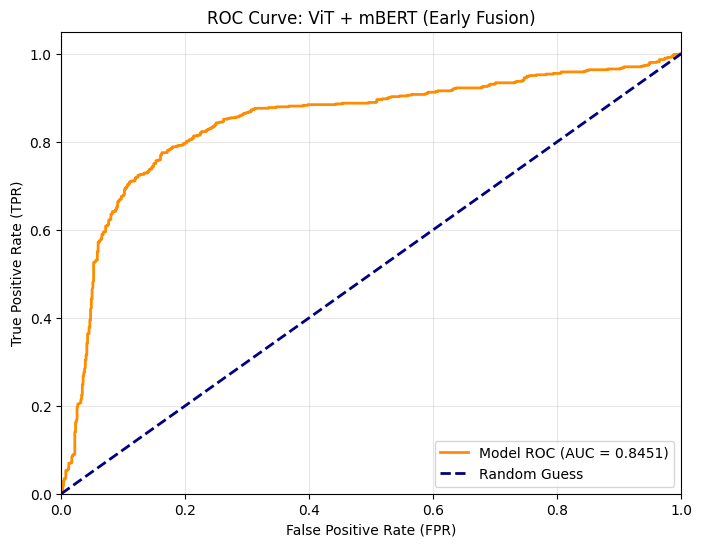

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import torch
import torch.nn.functional as F
from tqdm import tqdm

# ==========================================
# 1. Gather Probabilities
# ==========================================
model.eval()
y_true_roc  = []
y_probs_roc = []

print("Gathering probabilities for ROC curve...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="ROC Inference"):
        input_ids      = batch['input_ids'].to(Config['DEVICE'])
        attention_mask = batch['attention_mask'].to(Config['DEVICE'])
        token_type_ids = batch['token_type_ids'].to(Config['DEVICE'])
        images         = batch['image'].to(Config['DEVICE'])
        labels         = batch['label'].to(Config['DEVICE'])

        outputs = model(input_ids, attention_mask, token_type_ids, images)

        # Apply softmax to get probabilities across all classes
        probs = F.softmax(outputs, dim=1)

        # Extract probabilities for the positive class (Clickbait = 1)
        positive_class_probs = probs[:, 1]

        y_true_roc.extend(labels.cpu().numpy())
        y_probs_roc.extend(positive_class_probs.cpu().numpy())

# ==========================================
# 2. Calculate ROC and AUC
# ==========================================
fpr, tpr, thresholds = roc_curve(y_true_roc, y_probs_roc)
roc_auc = auc(fpr, tpr)

print(f"\n✅ ROC AUC Score: {roc_auc:.4f}")

# ==========================================
# 3. Plot ROC Curve
# ==========================================
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Model ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve: ViT + mBERT (Early Fusion)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()